In [3]:
!pip install git+https://github.com/KrishnaswamyLab/omics_toolbox.git --no-deps

DEPRECATION: Loading egg at /Users/joaofelipe/.local/lib/python3.11/site-packages/magic_impute-3.0.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
  Cloning https://github.com/KrishnaswamyLab/omics_toolbox.git to /private/var/folders/1r/l8_zwkvx7_g7b632hf_1517c0000gn/T/pip-req-build-v71zvwry
  Running command git clone --filter=blob:none --quiet https://github.com/KrishnaswamyLab/omics_toolbox.git /private/var/folders/1r/l8_zwkvx7_g7b632hf_1517c0000gn/T/pip-req-build-v71zvwry
  Resolved https://github.com/KrishnaswamyLab/omics_toolbox.git to commit 8a6e477d2351f487f980cd16a39f9b5da4f7e738
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Embryoid Body: PHATE Embedding and MIOFlow Preprocessing

This notebook combines the PHATE tutorial on Embryoid Body (EB) data with preprocessing steps required for MIOFlow.

We cover:
1. [Loading 10X data](#loading)
2. [Preprocessing: Filtering, Normalizing, and Transforming](#preprocessing)
3. [Dimensionality Reduction with PCA + PHATE](#pca-phate)
4. [Preparing Data for MIOFlow](#mioflow-prep)

## 0. Installation

Run the cell above to install `omics_toolbox`, which bundles all required dependencies (`phate`, `scanpy`, etc.).

## 1. Import Libraries

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import phate
import omics_toolbox as ot

## 2. Loading 10X Data

### Downloading Data from Mendeley Datasets

The EB dataset is publicly available as `scRNAseq.zip` at Mendeley Datasets at <https://data.mendeley.com/datasets/v6n743h5ng/>.

Inside the scRNAseq folder, there are five subdirectories, and in each subdirectory are three files: `barcodes.tsv`, `genes.tsv`, and `matrix.mtx`. For more information about how CellRanger produces these files, check out the [Gene-Barcode Matrices Documentation](https://support.10xgenomics.com/single-cell-gene-expression/software/pipelines/latest/output/matrices).

```
download_path
└── scRNAseq
    ├── T0_1A
    │   ├── barcodes.tsv
    │   ├── genes.tsv
    │   └── matrix.mtx
    ├── T2_3B
    ├── T4_5C
    ├── T6_7D
    └── T8_9E
```

If you have already downloaded the files, set `download_path` below to the directory where you saved them. Otherwise, the following code will download the data (~746MB) for you.

In [5]:
data_path = ot.download_embryoid_body(download_path='../../data/raw')  # downloads to ~/scRNAseq by default

Dataset already exists at: ../../data/raw/scRNAseq — skipping download.


Scanpy's `read_10x_mtx` reads the standard 10X CellRanger output format:
- `matrix.mtx` (expression matrix)
- `genes.tsv` (gene names)
- `barcodes.tsv` (cell barcodes)

In [6]:
samples = ['T0_1A', 'T2_3B', 'T4_5C', 'T6_7D', 'T8_9E']
labels = ['Day 00-03', 'Day 06-09', 'Day 12-15', 'Day 18-21', 'Day 24-27']

adatas = []
for sample, label in zip(samples, labels):
    adata = sc.read_10x_mtx(os.path.join(data_path, sample), var_names='gene_symbols', make_unique=True, cache=True)
    adata.obs['timepoint'] = label
    adatas.append(adata)

# Concatenate all samples
adata = sc.concat(adatas, merge='same')
adata.obs_names_make_unique()
print(f'Loaded {adata.n_obs} cells and {adata.n_vars} genes')

Loaded 31161 cells and 33694 genes


/Users/joaofelipe/Yale/github_projects/omics_toolbox/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 3. Preprocessing

### 3.1. Quality Control Metrics

Quality Control from scanpy's [documentation](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html):

_The scanpy function `calculate_qc_metrics()` calculates common quality control (QC) metrics. One can pass specific gene populations to calculate proportions of counts for these populations._

In [7]:
# Calculate QC metrics (including mitochondrial genes)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

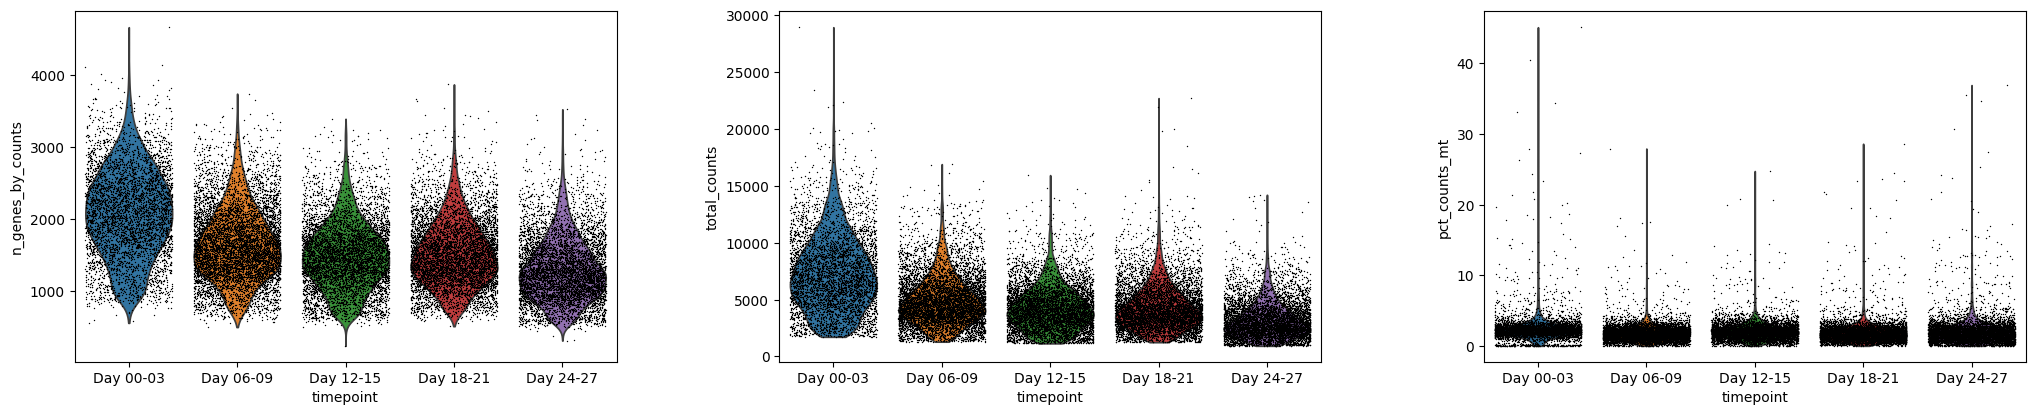

In [8]:
# Visualize QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, groupby='timepoint')

### 3.2. Library Size Filtering

We filter out cells with very large or very small library sizes on a per-sample basis, eliminating the top and bottom percentiles for each sample.

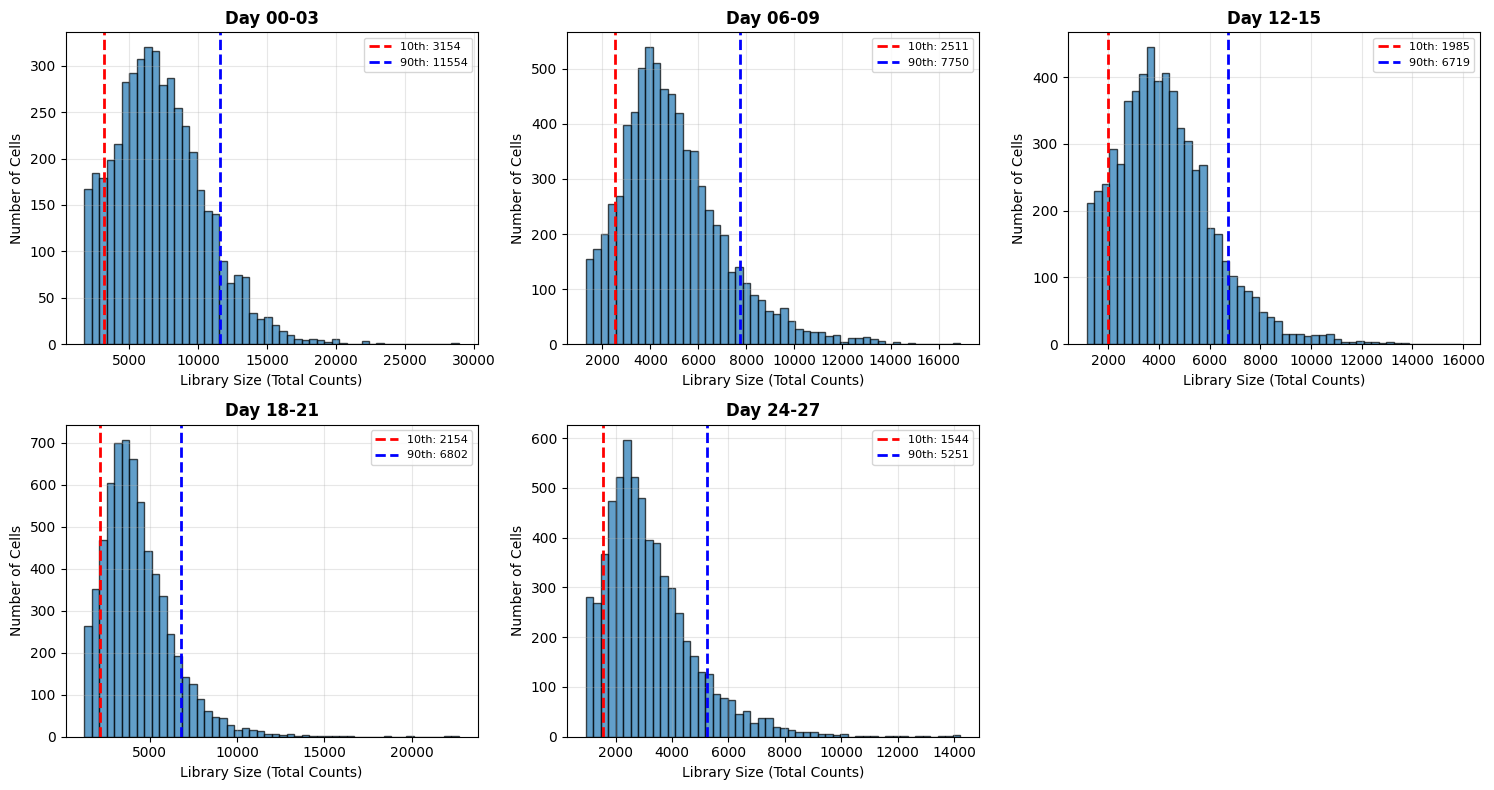

In [9]:
min_percentile = 10  # Filter cells below the 10th percentile
max_percentile = 90  # Filter cells above the 90th percentile

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (sample, label) in enumerate(zip(samples, labels)):
    sample_mask = adata.obs['timepoint'] == label
    sample_counts = adata.obs.loc[sample_mask, 'total_counts']

    threshold_min = np.percentile(sample_counts, min_percentile)
    threshold_max = np.percentile(sample_counts, max_percentile)

    axes[idx].hist(sample_counts, bins=50, alpha=0.7, edgecolor='black')
    axes[idx].axvline(threshold_min, color='red', linestyle='--', linewidth=2,
                      label=f'{min_percentile}th: {threshold_min:.0f}')
    axes[idx].axvline(threshold_max, color='blue', linestyle='--', linewidth=2,
                      label=f'{max_percentile}th: {threshold_max:.0f}')
    axes[idx].set_xlabel('Library Size (Total Counts)', fontsize=10)
    axes[idx].set_ylabel('Number of Cells', fontsize=10)
    axes[idx].set_title(label, fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [10]:
# Filter cells per sample based on library size percentiles
cells_to_keep = []

for sample, label in zip(samples, labels):
    sample_mask = adata.obs['timepoint'] == label
    sample_counts = adata.obs.loc[sample_mask, 'total_counts']

    threshold_min = np.percentile(sample_counts, min_percentile)
    threshold_max = np.percentile(sample_counts, max_percentile)

    keep_mask = (sample_counts >= threshold_min) & (sample_counts <= threshold_max)
    cells_to_keep.extend(sample_counts[keep_mask].index.tolist())

    print(f'{label}: keeping {keep_mask.sum()}/{len(sample_counts)} cells '
          f'(range: {threshold_min:.0f} - {threshold_max:.0f})')

adata = adata[cells_to_keep, :].copy()
print(f'\nTotal cells after filtering: {adata.n_obs}')

Day 00-03: keeping 3719/4649 cells (range: 3154 - 11554)
Day 06-09: keeping 5903/7377 cells (range: 2511 - 7750)
Day 12-15: keeping 4995/6245 cells (range: 1985 - 6719)
Day 18-21: keeping 5250/6563 cells (range: 2154 - 6802)
Day 24-27: keeping 5061/6327 cells (range: 1544 - 5251)

Total cells after filtering: 24928


### 3.3. Removing Rare Genes

Eliminate genes expressed in 10 cells or fewer.

In [11]:
min_cells = 10
sc.pp.filter_genes(adata, min_cells=min_cells)

### 3.4. Normalization

To correct for differences in library sizes, we divide each cell by its library size and rescale by the median library size.

In [12]:
sc.pp.normalize_total(adata, target_sum=np.median(adata.obs['total_counts']))

### 3.5. Dead Cell Removal

Dead cells tend to have higher mitochondrial RNA expression. We remove cells above the 90th percentile in mitochondrial content.

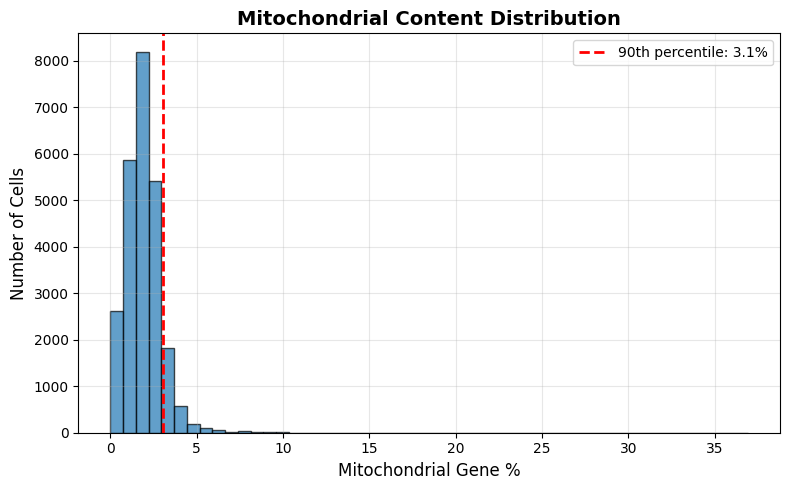

In [13]:
mito_pct = adata.obs['pct_counts_mt']
mito_percentile = 90
mito_threshold = np.percentile(mito_pct, mito_percentile)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(mito_pct, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(mito_threshold, color='red', linestyle='--', linewidth=2,
           label=f'{mito_percentile}th percentile: {mito_threshold:.1f}%')
ax.set_xlabel('Mitochondrial Gene %', fontsize=12)
ax.set_ylabel('Number of Cells', fontsize=12)
ax.set_title('Mitochondrial Content Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
adata = adata[adata.obs['pct_counts_mt'] < mito_threshold].copy()

### 3.6. Transformation

We use the square root transform instead of log1p — it has a similar compressive effect but is stable at zero.

In [15]:
# sc.pp.log1p(adata)  # Alternative: log1p transform
adata.X = np.sqrt(adata.X)

## 4. Dimensionality Reduction with PCA + PHATE

For MIOFlow we embed into a lower-dimensional PCA space first, then run PHATE on top of it. This reduces noise and speeds up downstream computation.

### 4.1. PCA

In [16]:
n_components = 50
sc.pp.pca(adata, n_comps=n_components)
print(adata)

AnnData object with n_obs × n_vars = 22435 × 18507
    obs: 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'timepoint_colors', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'


### 4.2. PHATE on PCA Space

PHATE follows the scikit-learn API. Key parameters:

- `knn`: Number of nearest neighbors (default: 5). Increase for large or disconnected datasets.
- `decay`: Alpha decay (default: 15). Controls graph connectivity.
- `t`: Diffusion time (default: `'auto'`). Controls smoothing.
- `gamma`: Informational distance constant (default: 1).

Calculating PHATE...
  Running PHATE on 22435 observations and 50 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.26 seconds.
    Calculating affinities...
    Calculated affinities in 0.96 seconds.
  Calculated graph and diffusion operator in 1.25 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 1.16 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.26 seconds.
  Calculated landmark operator in 4.42 seconds.
  Calculating optimal t...
    Automatically selected t = 22
  Calculated optimal t in 1.62 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.38 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 2.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.49 seconds.
Calculated PHATE in 9.70 seconds.


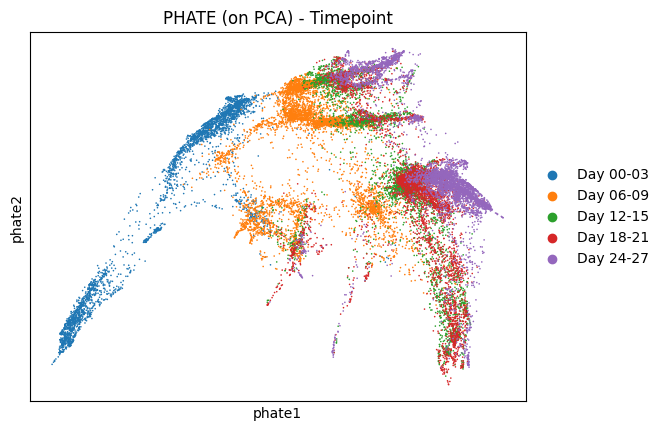

In [17]:
phate_operator = phate.PHATE(n_jobs=-2, n_components=2, verbose=True)
adata.obsm['X_phate'] = phate_operator.fit_transform(adata.obsm['X_pca'])

sc.pl.embedding(adata, basis='phate', color='timepoint', cmap='Spectral', title='PHATE (on PCA) - Timepoint')

## 5. Visualize gene expression on PHATE

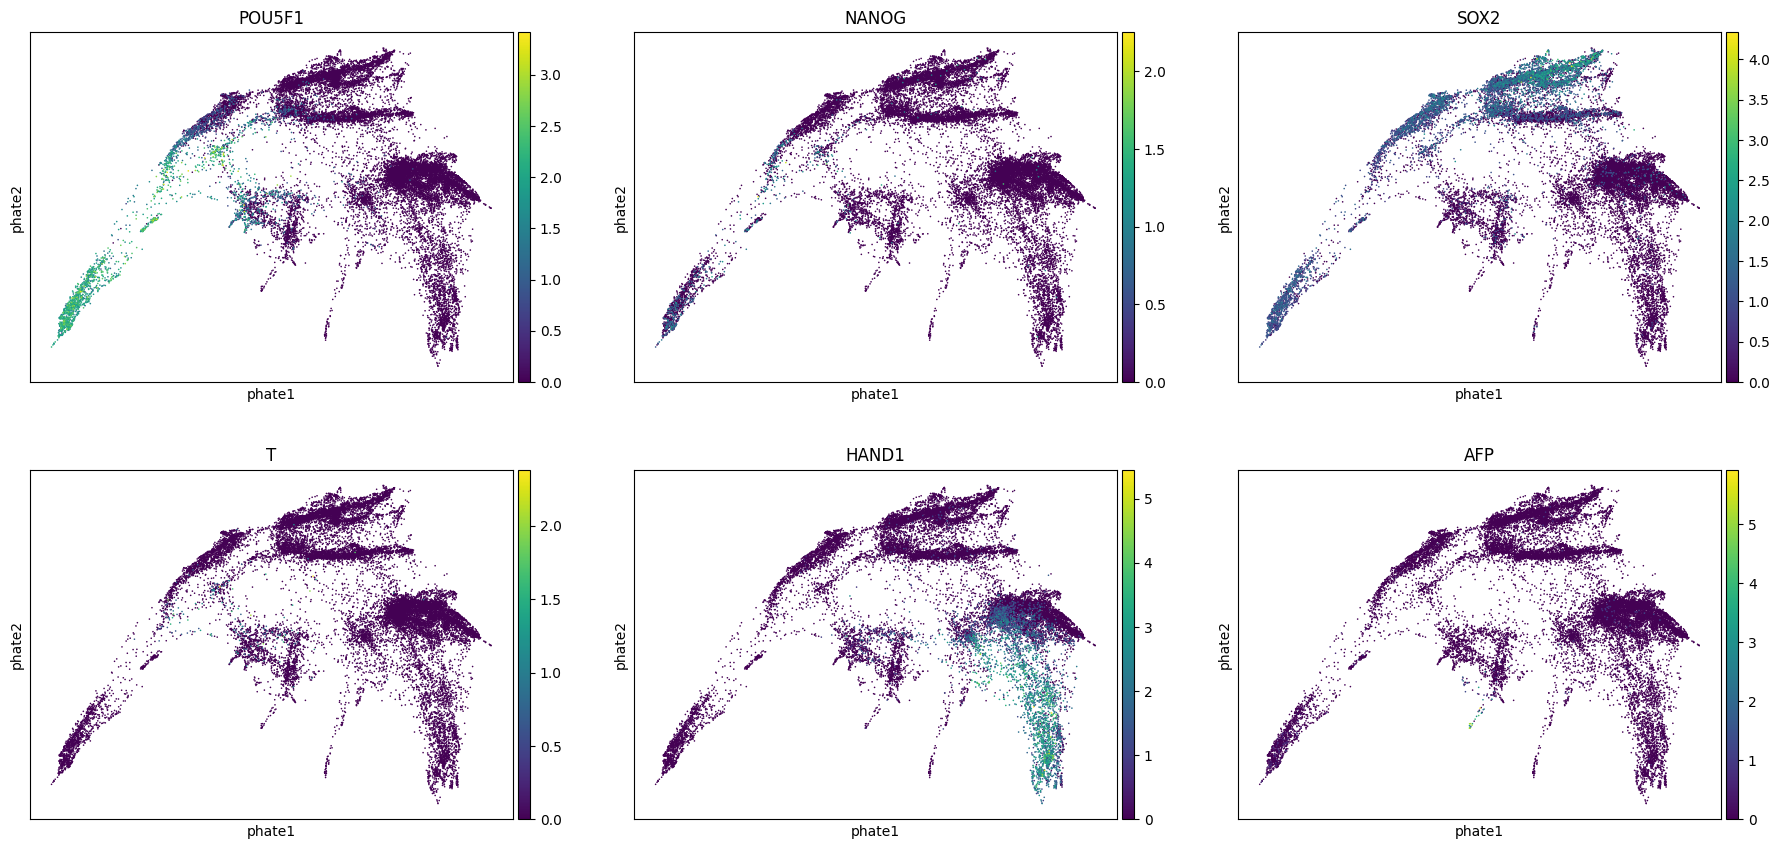

In [18]:

genes = ['POU5F1', 'NANOG', 'SOX2', 'T', 'HAND1', 'AFP']
sc.pl.embedding(adata, basis='phate', color=genes, cmap='viridis', ncols=3)

## 6. Preparing Data for MIOFlow

MIOFlow expects discrete time labels to guide trajectory inference. We create a `time_bin` column mapping each timepoint to an integer.

In [19]:
print('Creating time_bin from timepoints...')
adata.obs['time_bin'] = adata.obs['timepoint'].map({
    'Day 00-03': 0.,
    'Day 06-09': 1.,
    'Day 12-15': 2.,
    'Day 18-21': 3.,
    'Day 24-27': 4.,
})
adata.obs[['timepoint', 'time_bin']].head()

Creating time_bin from timepoints...


,timepoint,time_bin
AAACATTGAAGTGA-1,Day 00-03,0.0
AAACATTGGAGGTG-1,Day 00-03,0.0
AAACATTGGTTTCT-1,Day 00-03,0.0
AAACCGTGCAGAAA-1,Day 00-03,0.0
AAACGCACCGGTAT-1,Day 00-03,0.0


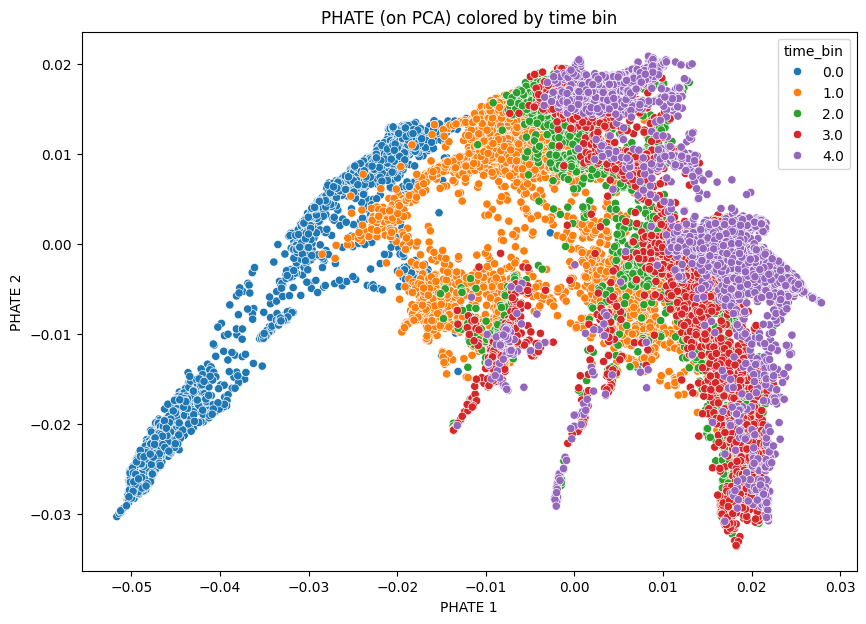

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    x=adata.obsm['X_phate'][:, 0],
    y=adata.obsm['X_phate'][:, 1],
    hue=adata.obs['time_bin'],
    palette='tab10',
    ax=ax
)
ax.set_xlabel('PHATE 1')
ax.set_ylabel('PHATE 2')
ax.set_title('PHATE (on PCA) colored by time bin')
plt.show()

### 5.1. Saving the Preprocessed Data

Save the fully preprocessed `AnnData` object so downstream MIOFlow notebooks can load it directly without repeating preprocessing.

In [21]:
save_path = os.path.join(data_path, 'preprocessed_adata.h5ad')
adata.write_h5ad(save_path)
print(f'Saved preprocessed AnnData to: {save_path}')
print(adata)

Saved preprocessed AnnData to: ../../data/raw/scRNAseq/preprocessed_adata.h5ad
AnnData object with n_obs × n_vars = 22435 × 18507
    obs: 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'time_bin'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'timepoint_colors', 'pca'
    obsm: 'X_pca', 'X_phate'
    varm: 'PCs'
